In [1]:
!pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.6 MB/s eta 0:00:00


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [ ]:
load_dotenv()

api_key = ""  

if not api_key or api_key == "YOUR_API_KEY_HERE":
    raise ValueError("Please set api_key to your actual GOOGLE_API_KEY")

In [4]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    api_key=api_key,
    streaming=True
)

In [5]:
MAX_TOKENS = 150

In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [ ]:
def count_tokens_approximately(messages):
    """
    Approximate token count for messages.
    For Google Generative AI models, counts approximately 1 token per word + 5 tokens per message.
    """
    total_tokens = 0
    for message in messages:
        if isinstance(message, dict):
            content = message.get("content", "")
        else:
            content = message.content if hasattr(message, "content") else str(message)
        
        # Approximate: ~1 token per word + 5 tokens for message overhead
        word_count = len(str(content).split())
        total_tokens += word_count + 5
    
    return total_tokens

In [27]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

In [28]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

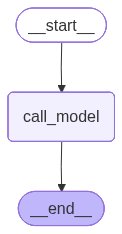

In [29]:
graph

In [12]:
pip install -U langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 8.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.23
    Uninstalling langchain-core-1.2.23:
      Successfully uninstalled langchain-core-1.2.23


In [30]:
from langchain_core.messages import trim_messages

config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Poras Nehra ."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 12
Hi, my name is Poras Nehra .


"Hello Poras! It's nice to meet you.\n\nHow can I help you today?"

In [31]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Poras Nehra .
Hello Poras! It's nice to meet you.

How can I help you today?
I am learning LangGraph.


"That's excellent, Poras! LangGraph is a powerful and fascinating library for building robust, stateful, and agentic applications with LLMs. It really helps bring structure and control to complex LLM workflows.\n\nWhat specifically about LangGraph are you currently exploring or finding interesting? For example:\n\n*   Are you working on understanding its **core concepts** (nodes, edges, state, graph compilation)?\n*   Are you trying to build a specific **type of application** (e.g., a multi-agent system, a RAG pipeline with decision making, a stateful chatbot)?\n*   Are you curious about **specific features** (e.g., human-in-the-loop, cycles, checkpoints, custom tools)?\n*   Are you looking for **examples** or **best practices**?\n*   Are you encountering any **challenges** or have specific **questions**?\n\nFeel free to ask me anything, whether it's for explanations, code snippets, architectural ideas, or just to discuss concepts!"

In [32]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 148
That's excellent, Poras! LangGraph is a powerful and fascinating library for building robust, stateful, and agentic applications with LLMs. It really helps bring structure and control to complex LLM workflows.

What specifically about LangGraph are you currently exploring or finding interesting? For example:

*   Are you working on understanding its **core concepts** (nodes, edges, state, graph compilation)?
*   Are you trying to build a specific **type of application** (e.g., a multi-agent system, a RAG pipeline with decision making, a stateful chatbot)?
*   Are you curious about **specific features** (e.g., human-in-the-loop, cycles, checkpoints, custom tools)?
*   Are you looking for **examples** or **best practices**?
*   Are you encountering any **challenges** or have specific **questions**?

Feel free to ask me anything, whether it's for explanations, code snippets, architectural ideas, or just to discuss concepts!
Can you explain short term memory?


'That\'s a fantastic question, as "short-term memory" has a slightly different, though analogous, meaning in cognitive psychology versus in the context of AI, particularly Large Language Models (LLMs).\n\nLet\'s break it down:\n\n---\n\n### 1. Short-Term Memory in Human Cognition\n\nIn cognitive psychology, Short-Term Memory (STM) is a temporary storage system that holds a limited amount of information for a brief period of time.\n\n*   **Capacity:** It\'s very limited, often cited as holding about 7 ± 2 "chunks" of information (Miller\'s Law). A "chunk" can be a single letter, a word, or even a meaningful phrase.\n*   **Duration:** Information is held for a very short duration, typically around 15-30 seconds without rehearsal (repeating the information to yourself).\n*   **Conscious Awareness:** It\'s the information you are currently aware of and actively processing.\n*   **Vulnerability:** It\'s easily disrupted by new incoming information or distractions.\n\n**Example:** When someo

In [33]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 9
What is my name?


"As an AI, I don't have access to your personal information, so I don't know your name."

In [35]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)


Hi, my name is Poras Nehra .
Hello Poras! It's nice to meet you.

How can I help you today?
I am learning LangGraph.
That's excellent, Poras! LangGraph is a powerful and fascinating library for building robust, stateful, and agentic applications with LLMs. It really helps bring structure and control to complex LLM workflows.

What specifically about LangGraph are you currently exploring or finding interesting? For example:

*   Are you working on understanding its **core concepts** (nodes, edges, state, graph compilation)?
*   Are you trying to build a specific **type of application** (e.g., a multi-agent system, a RAG pipeline with decision making, a stateful chatbot)?
*   Are you curious about **specific features** (e.g., human-in-the-loop, cycles, checkpoints, custom tools)?
*   Are you looking for **examples** or **best practices**?
*   Are you encountering any **challenges** or have specific **questions**?

Feel free to ask me anything, whether it's for explanations, code snippets